# Set up and download - Molecular cartography data from Legnini et al., 2023 

This tutorials shows how to set up an multiple slide molecular cartography dataset used from [Legnini et al., 2023](https://doi.org/10.1038/s41592-023-01986-w). To follow along with this and the following tutorials, please execute the following steps first:

- Set up InterScale environment (see instructions in [installation](../installation))
- Download the sample data from the original publication from [Zenodo](https://doi.org/10.5281/zenodo.6143560) under the accession no. 6143561

In [2]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse, csr_matrix
import seaborn as sns
from pathlib import Path

import warnings

warnings.filterwarnings("ignore")

In [3]:
from interscale import datasets as ds
from interscale.pp import compute_neighborhood_stats

In [4]:
Path.cwd().resolve().parent.parent

PosixPath('/dss/dsshome1/05/di93tig/1_projects/A3/interscale')

In [6]:
from pathlib import Path
import sys

# Find repo root by locating paths.py
BASE_DIR_PROJECT = Path.cwd().resolve().parent.parent

sys.path.insert(0, str(BASE_DIR_PROJECT))
DATA = "legnini"

Select the sample IDs for plotting: 

- `slide4_A2-3`: Control
- `slide4_B2-2`: SHH

In [7]:
sample_id = ["slide4_A2-3", "slide4_B2-2"]

## Load data

In [8]:
adata = ds.legnini(f"{BASE_DIR_PROJECT}/data/{DATA}")

In [9]:
adata

AnnData object with n_obs × n_vars = 43910 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'raw'

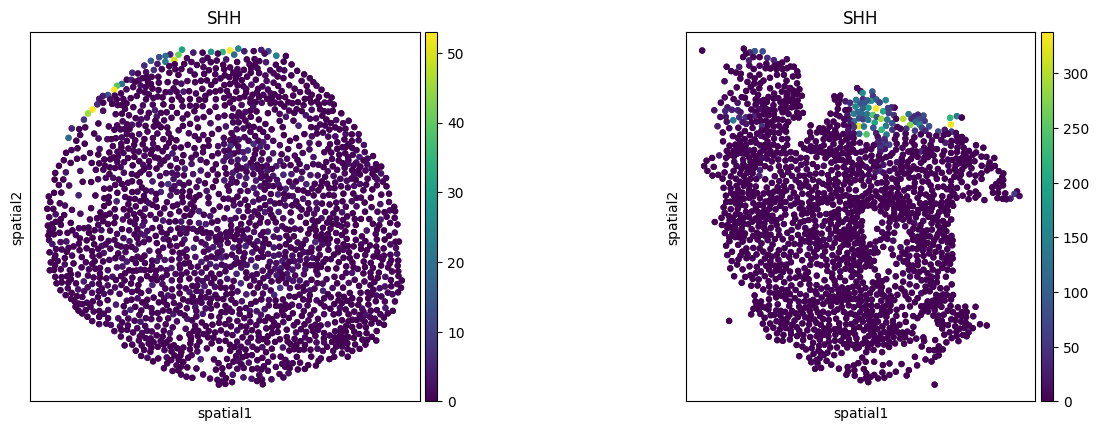

In [81]:
sq.pl.spatial_scatter(
    adata, color=["SHH"], spatial_key="spatial", library_key="sample", library_id=sample_id, shape=None, size=50
)

In [82]:
print("Zero count cells: ", (adata.X.sum(1) == 0).sum())

Zero count cells:  648


In [83]:
np.isnan(adata.obsm["spatial"]).sum()

296

Remove all cells that have entry NaN in `.obsm['coordinates']`.
If NaN is in .obsm it leads to error when creating graph. 

In [10]:
# Create a boolean mask for rows without NaN coordinates
valid_coords = ~np.isnan(adata.obsm["spatial"]).any(axis=1)

# Filter the AnnData object
adata = adata[valid_coords].copy()

# Verify the removal of NaN values
print(f"NaN values remaining: {np.isnan(adata.obsm['spatial']).sum()}")

NaN values remaining: 0


## 1. Normalization

The data needs to be normalized for InterScale (Ideally, counts should be normalized between 0 to 3). Check if the data is already normalized: 

In [11]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["raw"] = adata.X
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

In [12]:
# Freeman-Tukey square root transform
assert issparse(adata.X)
sqrt_X = adata.X.sqrt()
# Create a new sparse matrix for X + 1
X_plus_1 = adata.X + csr_matrix(np.ones(adata.X.shape))
# Calculate the square root of (X + 1)
sqrt_X_plus_1 = X_plus_1.sqrt()
adata.layers["norm_ftsqrt"] = sqrt_X + sqrt_X_plus_1

In [13]:
# shifted Logarithm
scales_counts = sc.pp.normalize_total(adata, target_sum=10000, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

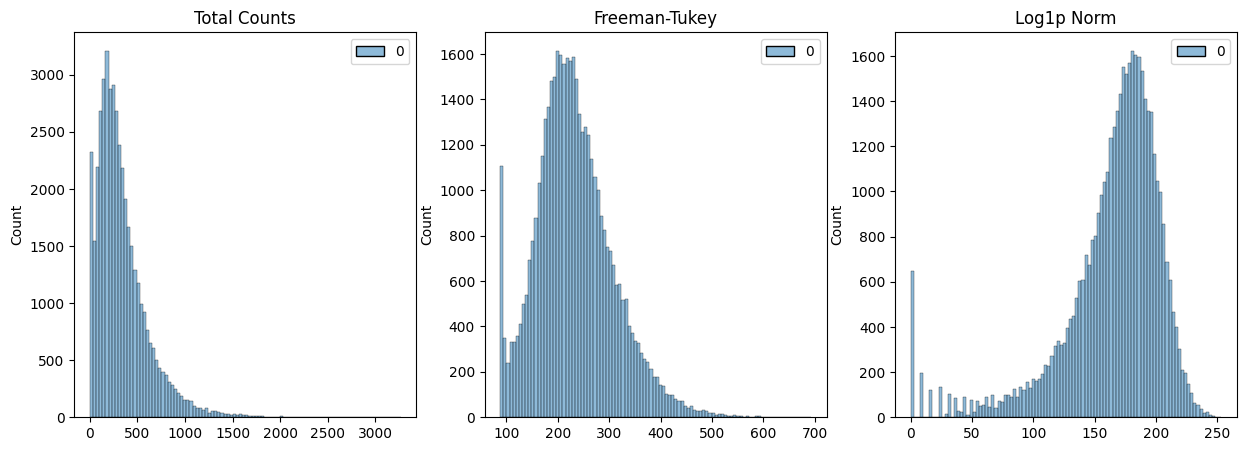

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
p0 = sns.histplot(adata.layers["raw"].sum(1), bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total Counts")
p1 = sns.histplot(adata.layers["norm_ftsqrt"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Freeman-Tukey")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[2])
axes[2].set_title("Log1p Norm")
plt.show()

In [15]:
print("Raw - Min: ", {adata.layers["raw"].min()}, ", Max: ", {adata.layers["raw"].max()})
print("Log1pNorm - Min: ", {adata.layers["log1p_norm"].min()}, ", Max: ", {adata.layers["log1p_norm"].max()})
print("NormTRSqrt - Min: ", {adata.layers["norm_ftsqrt"].min()}, ", Max: ", {adata.layers["norm_ftsqrt"].max()})

Raw - Min:  {0.0} , Max:  {603.0}
Log1pNorm - Min:  {0.0} , Max:  {9.210441}
NormTRSqrt - Min:  {1.0} , Max:  {49.132470338556004}


## 2. Calculate spatial connectivity matrix

Use [`squidpy.gr.spatial_neighbors()`](https://squidpy.readthedocs.io/en/stable/api/squidpy.gr.spatial_neighbors.html)) to calculate the spatial connectivity. For image-based ST it is important to set `coord_type='generic'`. In Squidpy, you have the option between k-nearest neighbors, delaunay and radius based neighborhood. For InterScale, we use a `radius`-based neighborhood to capture density information. Find the radius for which the number of connected neighbors is approximately 10-30, depending on tissue density. 

In [20]:
stats = compute_neighborhood_stats(adata, radii=[0, 200, 300], library_key="sample")

Radius: 0, Average Neighbors: 0.00, Std Dev: 0.00
Radius: 200, Average Neighbors: 10.14, Std Dev: 2.96
Radius: 300, Average Neighbors: 23.13, Std Dev: 5.95


{0: (0.0, 0.0),
 200: (10.140852794662036, 2.9614303205972354),
 300: (23.12983867282117, 5.954173240942826)}

Make sure that obs_names are unique and convertable to string. 

In [91]:
adata.obs_names_make_unique

<bound method AnnData.obs_names_make_unique of AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid'
    var: 'gene_ids', 'feature_types'
    uns: 'spatial_neighbors'
    obsm: 'spatial'
    layers: 'raw', 'log1p_norm', 'norm_ftsqrt'
    obsp: 'spatial_connectivities', 'spatial_distances'>

In [92]:
adata.obs["obs_names"] = adata.obs_names

In [93]:
sq.gr.spatial_neighbors(
    adata,
    coord_type="generic",
    library_key="sample",
    radius=300,
)

In [94]:
# Calculate nr. of neighbors per cells
conn = adata.obsp["spatial_connectivities"]
# Print average number of connections per node
avg_connections = conn.nnz / conn.shape[0]  # total connections / number of nodes
print(f"Average number of connections per node: {avg_connections:.2f}")

Average number of connections per node: 23.13


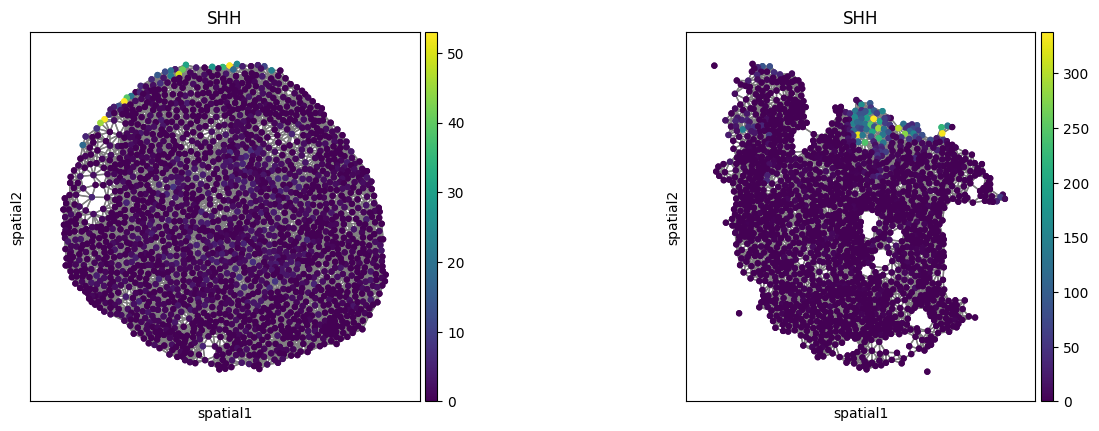

In [95]:
sq.pl.spatial_scatter(
    adata,
    color=["SHH"],
    spatial_key="spatial",
    library_key="sample",
    library_id=sample_id,
    shape=None,
    connectivity_key="spatial_connectivities",
    size=50,
)

## 3. Optional: Calculate sliding windows

Sliding windows are necessary in case the tissue slide contains more than 4k cells. First, check how many cells are at minimum or maximum in your dataset.

In [96]:
tissue_cell_number = adata.obs.groupby("sample").size()
print(
    f"Nr cells per sliding window: Min: {tissue_cell_number.min()}, Max: {tissue_cell_number.max()}, Avg: {tissue_cell_number.mean()}"
)

Nr cells per sliding window: Min: 1640, Max: 4318, Avg: 2574.235294117647


In case of the Legnini data, we set the maximum number of cells to `4318`.

In [97]:
MAX_CELLS = 4318

## 4. Optional: split data into train and val set

Training the model requires a `split` assignment for each donor/patient/sliding window that you wanna train on. 

In [99]:
df = adata.obs[["condition", "sample"]]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

condition  sample     
SHH        slide1_D2-2    4318
           slide1_D2-3    3621
           slide1_C2-2    3510
           slide4_B2-1    3345
           slide1_B2-1    3299
           slide1_A2-1    3023
Ctrl       slide1_C2-1    2870
SHH        slide4_A2-1    2630
           slide4_A2-2    2506
           slide1_B2-3    2241
Ctrl       slide4_A2-3    1984
           slide1_C2-5    1958
SHH        slide4_B2-2    1779
Ctrl       slide1_B2-2    1701
SHH        slide1_A2-2    1694
Ctrl       slide4_B2-3    1643
           slide1_C2-3    1640
Name: count, dtype: int64


In [100]:
adata.obs["split"] = "train"
# assign each one [Long-duration, ND, Onset]
adata.obs["split"][
    adata.obs["sample"].isin(["slide1_B2-1", "slide1_B2-3", "slide1_A2-2", "slide1_C2-3", "slide4_B2-3"])
] = "val"
adata.obs["split"][adata.obs["sample"].isin(sample_id)] = "test"

In [101]:
df = adata.obs[["split", "sample", "condition"]]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

split  sample       condition
train  slide1_D2-2  SHH          4318
       slide1_D2-3  SHH          3621
       slide1_C2-2  SHH          3510
       slide4_B2-1  SHH          3345
val    slide1_B2-1  SHH          3299
train  slide1_A2-1  SHH          3023
       slide1_C2-1  Ctrl         2870
       slide4_A2-1  SHH          2630
       slide4_A2-2  SHH          2506
val    slide1_B2-3  SHH          2241
test   slide4_A2-3  Ctrl         1984
train  slide1_C2-5  Ctrl         1958
test   slide4_B2-2  SHH          1779
train  slide1_B2-2  Ctrl         1701
val    slide1_A2-2  SHH          1694
       slide4_B2-3  Ctrl         1643
       slide1_C2-3  Ctrl         1640
Name: count, dtype: int64


## Save adata object

Save the prepared adata object such that it can be loaded for the model training. 

In [102]:
adata.write(f"{BASE_DIR_PROJECT}/data/{DATA}_pp.h5ad")

## Prepare config file

Duplicate the minum requirement config file from `/interscale/config_files/legnini_example.yaml` and add the necessary specification for the Visum data:

```
model:
  local_component:
    name: GCN
  global_component:
    name: self-attn-transformer
        max_seq_len: 2418
  save: /path/to/save/model/
dataset:
  h5ad_data: legnini22.h5ad
  name: legnini23
  sample_key: ['sample']
  spatial_neigbors_kwargs:
    coord_type: generic
    library_key: sample
    radius: 200
```


Save the config file as `.yaml` and proceed to training (either interactively in jupyter notebook or by running a script).